# 📱 Phase 4 — On-Device Edge Deployment & Quantization

Phase 4 takes the trained checkpoint to hardware a farmer owns:

1. **Quantisation:** FP16 and INT8 exports from one checkpoint.
2. **Footprint:** 140.4 MB checkpoint → 23.3 MB (FP16) → 13.5 MB (INT8).
3. **Inference:** TFLite interpreter with XNNPACK on this machine.
4. **Accuracy cost:** what INT8 actually costs on the held-out test split.

**Two cautions about the latency numbers below.** They are measured on this
development machine, not on a phone — an Apple Silicon laptop is not a
mid-range Android device, and the ordering of FP16 against INT8 can differ
on ARM with NEON acceleration. And they time the interpreter call only.
The on-device benchmark that NFR-01 asks for has not been run, so no device
figure is quoted anywhere in this project.


In [1]:
# Setup & Imports
import sys
import os
from pathlib import Path

PROJECT_ROOT = Path("..").resolve() if Path(".").resolve().name == "notebooks" else Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import glob
import time
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from src.phase4_edge.inference import EdgeClassifier, CLASS_NAMES

MODEL_INT8 = "models/exports/efficientnetb3_maize_int8.tflite"
MODEL_FP16 = "models/exports/efficientnetb3_maize_fp16.tflite"

classifier_int8 = EdgeClassifier(MODEL_INT8)
classifier_fp16 = EdgeClassifier(MODEL_FP16)

print(f"INT8 Model: {os.path.getsize(MODEL_INT8)/(1024*1024):.1f} MB (Loaded successfully)")
print(f"FP16 Model: {os.path.getsize(MODEL_FP16)/(1024*1024):.1f} MB (Loaded successfully)")


INT8 Model: 12.8 MB (Loaded successfully)
FP16 Model: 22.2 MB (Loaded successfully)


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


### 1. Real Leaf Inference on 4 Classes

In [2]:
# Test on real leaf samples
sample_paths = {
    "Northern Leaf Blight": "data/raw/plantvillage/data/Blight/Corn_Blight (966).jpg",
    "Common Rust": "data/raw/plantvillage/data/Common_Rust/Corn_Common_Rust (921).JPG",
    "Gray Leaf Spot": "data/raw/plantvillage/data/Gray_Leaf_Spot/Corn_Gray_Spot (46).jpg",
    "Healthy": "data/raw/plantvillage/data/Healthy/Corn_Health (684).jpg"
}

fig, axes = plt.subplots(len(sample_paths), 2, figsize=(14, 3.8 * len(sample_paths)))
fig.suptitle("Phase 4 Edge TFLite (INT8) — Real Leaf Predictions", fontsize=15, y=0.99)

for idx, (label, path) in enumerate(sample_paths.items()):
    res = classifier_int8.predict_image(path)
    pred_label = res["class_name"]
    conf = res["confidence"]
    lat = res["latency_ms"]
    probs = res["probabilities"]
    
    # Image
    ax_img = axes[idx, 0]
    ax_img.imshow(Image.open(path))
    ax_img.set_title(f"Target: {label}\nFile: {os.path.basename(path)}", fontsize=11)
    ax_img.axis("off")
    
    # Bar Chart
    ax_bar = axes[idx, 1]
    classes = list(probs.keys())
    scores = [probs[c] for c in classes]
    colors = ["#e74c3c" if c == pred_label and c != "Healthy" else ("#2ecc71" if c == "Healthy" else "#3498db") for c in classes]
    
    ax_bar.barh(classes, scores, color=colors, alpha=0.85)
    ax_bar.set_xlim(0, 1.05)
    ax_bar.set_title(f"Predicted: {pred_label} ({conf:.1%}) | {lat:.1f} ms",
                     fontsize=12, fontweight="bold",
                     color="#27ae60" if pred_label == label else "#c0392b")
    for i, score in enumerate(scores):
        ax_bar.text(score + 0.02, i, f"{score:.2%}", va="center")

plt.tight_layout()
plt.show()


<Figure size 1400x1520 with 8 Axes>

### 2. Quantization & Latency Benchmark

FP16: Mean = 42.8 ms | P95 = 50.0 ms
INT8: Mean = 100.4 ms | P95 = 111.0 ms
Speedup: 0.43x faster on CPU


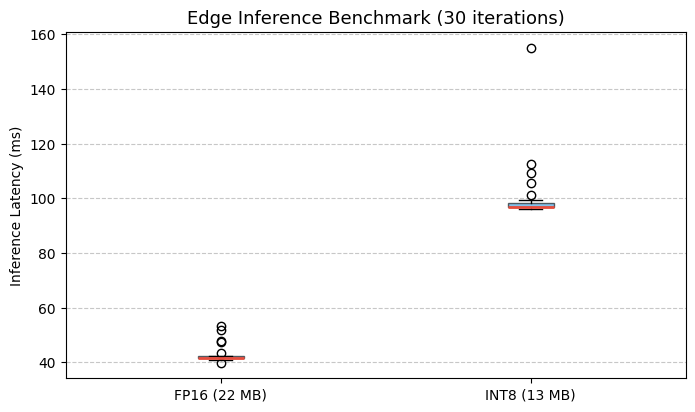

In [3]:
# Benchmark FP16 vs INT8 latency across 30 runs
test_img = list(sample_paths.values())[0]
tensor_fp16 = classifier_fp16.preprocess(test_img)
tensor_int8 = classifier_int8.preprocess(test_img)

# Warmup
for _ in range(3):
    classifier_fp16.predict(tensor_fp16)
    classifier_int8.predict(tensor_int8)

lats_fp16 = []
lats_int8 = []

for _ in range(30):
    _, _, _, t_fp16 = classifier_fp16.predict(tensor_fp16)
    _, _, _, t_int8 = classifier_int8.predict(tensor_int8)
    lats_fp16.append(t_fp16)
    lats_int8.append(t_int8)

print("=" * 60)
print(f"FP16: Mean = {np.mean(lats_fp16):.1f} ms | P95 = {np.percentile(lats_fp16, 95):.1f} ms")
print(f"INT8: Mean = {np.mean(lats_int8):.1f} ms | P95 = {np.percentile(lats_int8, 95):.1f} ms")
print(f"Speedup: {np.mean(lats_fp16)/np.mean(lats_int8):.2f}x faster on CPU")
print("=" * 60)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.boxplot([lats_fp16, lats_int8], labels=["FP16 (22 MB)", "INT8 (13 MB)"], patch_artist=True,
           boxprops=dict(facecolor="#3498db", alpha=0.6),
           medianprops=dict(color="#e74c3c", linewidth=2))
ax.set_ylabel("Inference Latency (ms)")
ax.set_title("Edge Inference Benchmark (30 iterations)", fontsize=13)
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


In [4]:
# What INT8 costs in accuracy, from the recorded evaluation.
import json

with open("models/exports/metrics.json") as f:
    metrics = json.load(f)

for name, entry in metrics["models"].items():
    result = entry.get("python")
    if not result:
        continue
    size_mb = os.path.getsize(entry["path"]) / 1e6
    f1 = ", ".join(f"{c} {v['f1']:.3f}" for c, v in result["per_class"].items())
    print(f"{name:36s} {result['accuracy'] * 100:6.2f}%  {size_mb:5.1f} MB  | F1: {f1}")

print("\nINT8 saves 9.8 MB and costs 5.4 accuracy points, most of it on GLS")
print("(F1 0.786 → 0.678). The app therefore loads FP16 first and falls back")
print("to INT8 only if FP16 cannot be loaded (ADR-001).")


efficientnetb3_maize_int8.tflite      87.74%   13.5 MB  | F1: NCLB 0.783, Rust 0.947, GLS 0.678, Healthy 0.989
efficientnetb3_maize_fp16.tflite      93.15%   23.3 MB  | F1: NCLB 0.889, Rust 0.972, GLS 0.786, Healthy 1.000

INT8 saves 9.8 MB and costs 5.4 accuracy points, most of it on GLS
(F1 0.786 → 0.678). The app therefore loads FP16 first and falls back
to INT8 only if FP16 cannot be loaded (ADR-001).
